<a href="https://colab.research.google.com/github/jessiepsx/Machine-Learning-Practitioner/blob/main/Treinamento_Rede_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# clone darknet repo
!git clone https://github.com/AlexeyAB/darknet

Cloning into 'darknet'...
remote: Enumerating objects: 15909, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 15909 (delta 2), reused 2 (delta 2), pack-reused 15903 (from 2)
Receiving objects: 100% (15909/15909), 14.43 MiB | 18.97 MiB/s, done.
Resolving deltas: 100% (10710/10710), done.


In [ ]:
# This cell imports the drive library and mounts your Google Drive as a VM local drive. You can access to your Drive files
# using this path "/content/gdrive/My Drive/"

from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# Not Necessary cell
# List the content of your local computer folder
!ls -la "/content/darknet"


total 296
drwxr-xr-x 13 root root  4096 Sep 14 02:28 .
drwxr-xr-x  1 root root  4096 Sep 14 02:28 ..
drwxr-xr-x  5 root root  4096 Sep 14 02:28 3rdparty
drwxr-xr-x  3 root root  4096 Sep 14 02:28 build
-rwxr-xr-x  1 root root 44371 Sep 14 02:28 build.ps1
drwxr-xr-x  3 root root  4096 Sep 14 02:28 cfg
drwxr-xr-x  2 root root  4096 Sep 14 02:28 .circleci
drwxr-xr-x  3 root root  4096 Sep 14 02:28 cmake
-rw-r--r--  1 root root 30396 Sep 14 02:28 CMakeLists.txt
-rw-r--r--  1 root root  1493 Sep 14 02:28 DarknetConfig.cmake.in
-rw-r--r--  1 root root  9559 Sep 14 02:28 darknet_images.py
-rw-r--r--  1 root root 11106 Sep 14 02:28 darknet.py
-rw-r--r--  1 root root  8000 Sep 14 02:28 darknet_video.py
drwxr-xr-x  3 root root  4096 Sep 14 02:28 data
-rw-r--r--  1 root root   366 Sep 14 02:28 docker-compose.yml
-rw-r--r--  1 root root   774 Sep 14 02:28 Dockerfile.cpu
-rw-r--r--  1 root root   834 Sep 14 02:28 Dockerfile.gpu
drwxr-xr-x  8 root root  4096 Sep 14 02:28 .git
drwxr-xr-x  4 root root

In [ ]:
!sudo apt-get install tree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (101 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package tree.
(Reading database ... 126374 files and directories currently install

In [ ]:
!tree /content/darknet/

/content/darknet/
├── 3rdparty
│   ├── getopt
│   │   ├── getopt.c
│   │   └── getopt.h
│   ├── pthreads
│   │   ├── bin
│   │   │   ├── pthreadGC2.dll
│   │   │   └── pthreadVC2.dll
│   │   ├── include
│   │   │   ├── pthread.h
│   │   │   ├── sched.h
│   │   │   └── semaphore.h
│   │   └── lib
│   │       ├── libpthreadGC2.a
│   │       └── pthreadVC2.lib
│   └── stb
│       └── include
│           ├── stb_image.h
│           └── stb_image_write.h
├── build
│   └── darknet
│       ├── darknet_no_gpu.sln
│       ├── darknet_no_gpu.vcxproj
│       ├── darknet.sln
│       ├── darknet.vcxproj
│       ├── x64
│       │   ├── backup
│       │   │   └── tmp.txt
│       │   ├── calc_anchors.cmd
│       │   ├── calc_mAP.cmd
│       │   ├── calc_mAP_coco.cmd
│       │   ├── calc_mAP_voc_py.cmd
│       │   ├── cfg
│       │   │   ├── alexnet.cfg
│       │   │   ├── cd53paspp-gamma.cfg
│       │   │   ├── cifar.cfg
│       │   │   ├── cifar.test.cfg
│       │   │   ├── coco.data
│       │   │   

In [ ]:
# This cell imports the drive library and mounts your Google Drive as a VM local drive.
# You can access to your Drive files using this path “/content/gdrive/My Drive/”
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [1]:
import cv2

In [ ]:
# This cell can be commented once you checked the current CUDA version
# CUDA: Let's check that Nvidia CUDA is already pre-installed and which version is it. In some time from now maybe you
!/usr/local/cuda/bin/nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [ ]:
# We're unzipping the cuDNN files from your Drive folder directly to the VM CUDA folders
!tar -xvf gdrive/My\ Drive/darknet/cudnn-linux-x86_64-9.7.1.26_cuda12-archive.tar.xz -C /usr/local/
!chmod a+r /usr/local/cuda/include

tar: gdrive/My Drive/darknet/cudnn-linux-x86_64-9.7.1.26_cuda12-archive.tar.xz: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now


In [ ]:
# Now we check the version we already installed. Can comment this line on future runs
!cat /usr/local/cuda/include/cudnn.h | grep CUDNN_MAJOR -A 2

cat: /usr/local/cuda/include/cudnn.h: No such file or directory


In [ ]:
# Leave this code uncommented on the very first run of your notebook or if you ever need to recompile darknet again.
# Comment this code on the future runs.
%cd darknet

#Compile Darknet
!make

#Copies the Darknet compiled version to Google drive
!cp -r ./ /content/gdrive/MyDrive/darknet/bin/darknet

# Set execution permissions to Darknet
!chmod +x ./darknet

[Errno 20] Not a directory: 'darknet'
/content/darknet
chmod +x *.sh
^C


In [ ]:
# Uncomment after the first run, when you have a copy of compiled darkent in your Google Drive


# Makes a dir for darknet and move there
!mkdir darknet
%cd darknet


# Copy the Darkent compiled version to the VM local drive
!cp -r /content/gdrive/MyDrive/darknet/bin/darknet ./


# Set execution permissions to Darknet
!chmod +x ./darknet

mkdir: cannot create directory ‘darknet’: File exists
[Errno 20] Not a directory: 'darknet'
/content/darknet
cp: cannot overwrite non-directory './darknet' with directory '/content/gdrive/MyDrive/darknet/bin/darknet'


In [ ]:
#download files
def imShow(path):
  import cv2
  import matplotlib.pyplot as plt
  %matplotlib inline

  image = cv2.imread(path)
  height, width = image.shape[:2]
  resized_image = cv2.resize(image,(3*width, 3*height), interpolation = cv2.INTER_CUBIC)

  fig = plt.gcf()
  fig.set_size_inches(18, 10)
  plt.axis("off")
  #plt.rcParams['figure.figsize'] = [10, 5]
  plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
  plt.show()


def upload():
  from google.colab import files
  uploaded = files.upload()
  for name, data in uploaded.items():
    with open(name, 'wb') as f:
      f.write(data)
      print ('saved file', name)
def download(path):
  from google.colab import files
  files.download(path)

In [ ]:
# Not necessary cell
# Get yolov3 weights
!wget https://pjreddie.com/media/files/yolov3.weights

--2025-09-14 02:38:31--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 172.67.185.199, 104.21.88.156, 2606:4700:3030::ac43:b9c7, ...
Connecting to pjreddie.com (pjreddie.com)|172.67.185.199|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘yolov3.weights’

yolov3.weights          [ <=>                ]   8.88K  --.-KB/s    in 0s      

2025-09-14 02:38:31 (76.2 MB/s) - ‘yolov3.weights’ saved [9093]



In [ ]:
# Not necessary cell
# Execute darknet using YOLOv3 model with pre-trained weights to detect objects on 'person.jpg'
!./darknet detector test ./cfg/coco.data ./cfg/yolov3.cfg ./yolov3.weights /content/darknet/data/dog.jpg

#/content/darknet/data/dog.jpg

 GPU isn't used 
 OpenCV isn't used - data augmentation will be slow 
mini_batch = 1, batch = 1, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 conv     32       3 x 3/ 1    416 x 416 x   3 ->  416 x 416 x  32 0.299 BF
   1 conv     64       3 x 3/ 2    416 x 416 x  32 ->  208 x 208 x  64 1.595 BF
   2 conv     32       1 x 1/ 1    208 x 208 x  64 ->  208 x 208 x  32 0.177 BF
   3 conv     64       3 x 3/ 1    208 x 208 x  32 ->  208 x 208 x  64 1.595 BF
   4 Shortcut Layer: 1,  wt = 0, wn = 0, outputs: 208 x 208 x  64 0.003 BF
   5 conv    128       3 x 3/ 2    208 x 208 x  64 ->  104 x 104 x 128 1.595 BF
   6 conv     64       1 x 1/ 1    104 x 104 x 128 ->  104 x 104 x  64 0.177 BF
   7 conv    128       3 x 3/ 1    104 x 104 x  64 ->  104 x 104 x 128 1.595 BF
   8 Shortcut Layer: 5,  wt = 0, wn = 0, outputs: 104 x 104 x 128 0.001 BF
   9 conv     64       1 x 1/ 1    104 x 104 x 128 ->  104 x 104 x  64 0.177 BF
  10 conv    128  

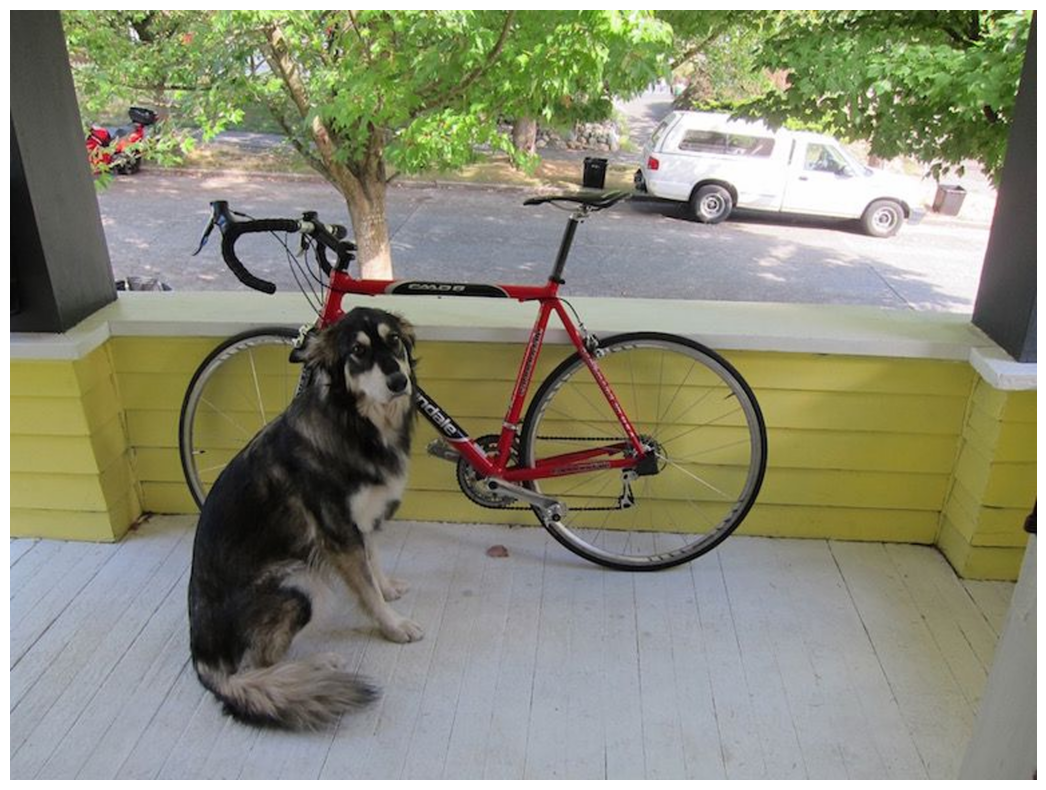

In [ ]:
imShow('predictions.jpg')